# Milestone 2 - Computer Vision: CNN vs Transfer Learning

This notebook uses product images to predict the product-level `rating_band` quality signal. It preserves the Milestone 0 product-level train/validation/test split, trains a small CNN from scratch, trains a MobileNetV2 transfer-learning model, and compares both models against a majority-class baseline.


## 0. Setup

The default image target is intentionally small for a notebook quick run. Set `MAX_CV_IMAGES_TO_CACHE=5000` before launching Jupyter for a fuller Milestone 2 run. The sample is split-aware: train, validation, and test images are selected separately so the cache is not dominated by the train split.


In [1]:
from __future__ import annotations

import hashlib
import os
import random
import time
from pathlib import Path
from urllib.parse import urlparse

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import tensorflow as tf
import certifi
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

# Let Keras download pretrained application weights on macOS/Python installs
# where the default SSL certificate store is not configured.
os.environ.setdefault("SSL_CERT_FILE", certifi.where())
os.environ.setdefault("REQUESTS_CA_BUNDLE", certifi.where())


'/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/certifi/cacert.pem'

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
IMAGE_CACHE_DIR = PROJECT_ROOT / "data" / "images" / "all_beauty"
REPORT_DIR = PROJECT_ROOT / "report"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODEL_DIR = PROJECT_ROOT / "models"

PRODUCT_TRAIN_PATH = PROCESSED_DIR / "product_train.parquet"
PRODUCT_VAL_PATH = PROCESSED_DIR / "product_val.parquet"
PRODUCT_TEST_PATH = PROCESSED_DIR / "product_test.parquet"
VISION_IMAGE_MANIFEST_PATH = PROCESSED_DIR / "vision_image_manifest.csv"
VISION_MODEL_COMPARISON_PATH = REPORT_DIR / "vision_model_comparison.csv"
VISION_MODEL_COMPARISON_COMPAT_PATH = REPORTS_DIR / "vision_model_comparison.csv"
VISION_PREDICTIONS_TEST_PATH = PROCESSED_DIR / "vision_predictions_test.csv"
SMALL_CNN_MODEL_PATH = MODEL_DIR / "vision_small_cnn.keras"
TRANSFER_MODEL_PATH = MODEL_DIR / "vision_mobilenetv2_transfer.keras"
VISION_LABEL_ENCODER_PATH = MODEL_DIR / "vision_label_encoder.joblib"

for directory in [PROCESSED_DIR, IMAGE_CACHE_DIR, REPORT_DIR, REPORTS_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MAX_CV_IMAGES_TO_CACHE = int(os.getenv("MAX_CV_IMAGES_TO_CACHE", "600"))
FULL_CV_IMAGE_TARGET = 5000
IMAGE_SIZE = (96, 96)
BATCH_SIZE = int(os.getenv("CV_BATCH_SIZE", "32"))
SMALL_CNN_EPOCHS = int(os.getenv("SMALL_CNN_EPOCHS", "12"))
TRANSFER_EPOCHS = int(os.getenv("TRANSFER_EPOCHS", "8"))
IMAGE_DOWNLOAD_TIMEOUT = int(os.getenv("IMAGE_DOWNLOAD_TIMEOUT", "10"))
USE_TRAIN_ON_BATCH_FALLBACK = os.getenv("USE_TRAIN_ON_BATCH_FALLBACK", "0") == "1"

print(f"Project root: {PROJECT_ROOT}")
print(f"Quick-run image target: {MAX_CV_IMAGES_TO_CACHE:,}")
print(f"Full CV milestone image target suggestion: {FULL_CV_IMAGE_TARGET:,}")


Project root: /Users/nazrinaliyeva/Desktop/smart_e_commerce_assistant
Quick-run image target: 60
Full CV milestone image target suggestion: 5,000


## 1. Load Product-Level Splits

These files are produced by Milestone 0. The split is product-level, so the same product cannot appear in multiple splits.


In [3]:
product_train = pd.read_parquet(PRODUCT_TRAIN_PATH)
product_val = pd.read_parquet(PRODUCT_VAL_PATH)
product_test = pd.read_parquet(PRODUCT_TEST_PATH)

required_columns = {"product_id", "primary_image_url", "rating_band", "target_rating"}
for split_name, df in {"train": product_train, "val": product_val, "test": product_test}.items():
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"{split_name} split is missing required columns: {sorted(missing)}")

split_sizes = pd.DataFrame({
    "split": ["train", "val", "test"],
    "products": [len(product_train), len(product_val), len(product_test)],
    "products_with_image_url": [
        int(product_train["primary_image_url"].notna().sum()),
        int(product_val["primary_image_url"].notna().sum()),
        int(product_test["primary_image_url"].notna().sum()),
    ],
})
display(split_sizes)

display(pd.concat({
    "train": product_train["rating_band"].value_counts(dropna=False),
    "val": product_val["rating_band"].value_counts(dropna=False),
    "test": product_test["rating_band"].value_counts(dropna=False),
}, axis=1).fillna(0).astype(int))


,split,products,products_with_image_url
0,train,17759,17759
1,val,3806,3806
2,test,3806,3806


,train,val,test
rating_band,,,
high,9549,2011,2009
low,5254,1149,1157
medium,2956,646,640


## 2. Product-Level Leakage Check

The following check must pass before image modeling. It confirms that product IDs do not overlap across train, validation, and test.


In [4]:
train_ids = set(product_train["product_id"].dropna().astype(str))
val_ids = set(product_val["product_id"].dropna().astype(str))
test_ids = set(product_test["product_id"].dropna().astype(str))

leakage_summary = {
    "train_val_overlap": len(train_ids & val_ids),
    "train_test_overlap": len(train_ids & test_ids),
    "val_test_overlap": len(val_ids & test_ids),
}
leakage_check_passed = all(value == 0 for value in leakage_summary.values())

print(leakage_summary)
print(f"Leakage check passed: {leakage_check_passed}")
if not leakage_check_passed:
    raise ValueError("Product-level leakage detected. Stop before training image models.")


{'train_val_overlap': 0, 'train_test_overlap': 0, 'val_test_overlap': 0}
Leakage check passed: True


## 3. Split-Aware Image Sampling and Cache

The quick-run target is allocated approximately 70% train, 15% validation, and 15% test. Within each split, products are sampled by `rating_band` as evenly as possible. Locally cached images are preferred to keep reruns fast, and any missing selected images are downloaded into the shared image cache.


In [5]:
MANIFEST_COLUMNS = [
    "split",
    "product_id",
    "primary_image_url",
    "cached_image_path",
    "image_cache_status",
    "image_cache_error",
]


def to_relative_path(path_value) -> str:
    if pd.isna(path_value) or str(path_value).strip() == "":
        return ""
    path = Path(str(path_value))
    if path.is_absolute():
        try:
            return str(path.relative_to(PROJECT_ROOT))
        except ValueError:
            return str(path)
    return str(path)


def path_exists(path_value) -> bool:
    rel = to_relative_path(path_value)
    return bool(rel) and (PROJECT_ROOT / rel).exists()


def image_filename(product_id: str, url: str) -> str:
    parsed = urlparse(str(url))
    suffix = Path(parsed.path).suffix.lower()
    if suffix not in {".jpg", ".jpeg", ".png", ".webp", ".gif"}:
        suffix = ".jpg"
    digest = hashlib.md5(str(url).encode("utf-8")).hexdigest()[:10]
    safe_product_id = str(product_id).replace("/", "_")
    return f"{safe_product_id}_{digest}{suffix}"


def load_existing_manifest(path: Path) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame(columns=MANIFEST_COLUMNS)
    manifest = pd.read_csv(path)
    for column in MANIFEST_COLUMNS:
        if column not in manifest.columns:
            manifest[column] = pd.NA
    manifest = manifest[MANIFEST_COLUMNS].copy()
    manifest["product_id"] = manifest["product_id"].astype(str)
    manifest["cached_image_path"] = manifest["cached_image_path"].fillna("").map(to_relative_path)
    missing_file = (manifest["image_cache_status"] == "cached") & ~manifest["cached_image_path"].map(path_exists)
    manifest.loc[missing_file, "image_cache_status"] = "missing_file"
    manifest.loc[missing_file, "cached_image_path"] = ""
    return manifest.drop_duplicates(["split", "product_id"], keep="last")


def allocate_image_budget(total: int) -> dict[str, int]:
    train_n = int(round(total * 0.70))
    val_n = int(round(total * 0.15))
    test_n = max(total - train_n - val_n, 0)
    return {"train": train_n, "val": val_n, "test": test_n}


def balanced_split_sample(df: pd.DataFrame, n: int, label_col: str = "rating_band") -> pd.DataFrame:
    candidates = df.dropna(subset=["product_id", "primary_image_url", label_col]).drop_duplicates("product_id").copy()
    if n <= 0 or candidates.empty:
        return candidates.head(0).copy()

    candidates["has_local_image"] = candidates.get("cached_image_path", "").map(path_exists) if "cached_image_path" in candidates else False
    labels = sorted(candidates[label_col].astype(str).unique())
    base = max(n // max(len(labels), 1), 1)
    remainder = n - base * len(labels)
    sampled_parts = []

    for idx, label in enumerate(labels):
        take = base + (1 if idx < remainder else 0)
        group = candidates[candidates[label_col].astype(str) == label].copy()
        group = group.sort_values(["has_local_image", "product_id"], ascending=[False, True])
        if len(group) > take:
            cached = group[group["has_local_image"]]
            uncached = group[~group["has_local_image"]]
            cached_take = min(len(cached), take)
            part = pd.concat([
                cached.sample(n=cached_take, random_state=SEED) if cached_take else cached.head(0),
                uncached.sample(n=take - cached_take, random_state=SEED) if take - cached_take > 0 else uncached.head(0),
            ])
        else:
            part = group
        sampled_parts.append(part)

    sampled = pd.concat(sampled_parts, ignore_index=True) if sampled_parts else candidates.head(0)
    if len(sampled) < n:
        remaining = candidates[~candidates["product_id"].astype(str).isin(sampled["product_id"].astype(str))]
        remaining = remaining.sort_values(["has_local_image", "product_id"], ascending=[False, True])
        extra_n = min(n - len(sampled), len(remaining))
        if extra_n > 0:
            sampled = pd.concat([sampled, remaining.head(extra_n)], ignore_index=True)
    return sampled.drop(columns=["has_local_image"], errors="ignore").head(n).copy()


def cache_split_images(split_name: str, split_df: pd.DataFrame, manifest_path: Path, timeout: int = IMAGE_DOWNLOAD_TIMEOUT) -> pd.DataFrame:
    manifest = load_existing_manifest(manifest_path)
    manifest_key = {
        (str(row.split), str(row.product_id)): row._asdict()
        for row in manifest.itertuples(index=False)
    }
    rows = manifest_key.copy()

    selected = split_df.dropna(subset=["product_id", "primary_image_url"]).drop_duplicates("product_id")
    total = len(selected)
    print(f"Caching/checking {total} selected {split_name} images...")

    for idx, row in enumerate(selected.itertuples(index=False), start=1):
        product_id = str(row.product_id)
        url = str(row.primary_image_url)
        key = (split_name, product_id)
        existing = manifest_key.get(key)

        if existing and existing.get("image_cache_status") == "cached" and path_exists(existing.get("cached_image_path")):
            rows[key] = existing
            continue

        current_cached_path = getattr(row, "cached_image_path", "") if hasattr(row, "cached_image_path") else ""
        if path_exists(current_cached_path):
            rows[key] = {
                "split": split_name,
                "product_id": product_id,
                "primary_image_url": url,
                "cached_image_path": to_relative_path(current_cached_path),
                "image_cache_status": "cached",
                "image_cache_error": "",
            }
            continue

        local_rel_path = Path("data") / "images" / "all_beauty" / image_filename(product_id, url)
        local_abs_path = PROJECT_ROOT / local_rel_path
        if local_abs_path.exists():
            rows[key] = {
                "split": split_name,
                "product_id": product_id,
                "primary_image_url": url,
                "cached_image_path": str(local_rel_path),
                "image_cache_status": "cached",
                "image_cache_error": "",
            }
            continue

        try:
            response = requests.get(url, timeout=timeout, headers={"User-Agent": "Mozilla/5.0"})
            response.raise_for_status()
            local_abs_path.write_bytes(response.content)
            cached_path = str(local_rel_path)
            status = "cached"
            error = ""
        except Exception as exc:
            cached_path = ""
            status = "failed"
            error = str(exc)[:250]

        rows[key] = {
            "split": split_name,
            "product_id": product_id,
            "primary_image_url": url,
            "cached_image_path": cached_path,
            "image_cache_status": status,
            "image_cache_error": error,
        }

        if idx % 50 == 0 or idx == total:
            out = pd.DataFrame(rows.values(), columns=MANIFEST_COLUMNS)
            out.to_csv(manifest_path, index=False)
            print(f"  {split_name}: {idx}/{total} checked")

    out = pd.DataFrame(rows.values(), columns=MANIFEST_COLUMNS)
    out = out.drop_duplicates(["split", "product_id"], keep="last") if not out.empty else pd.DataFrame(columns=MANIFEST_COLUMNS)
    out.to_csv(manifest_path, index=False)
    return out[out["split"].astype(str) == split_name].copy()


def attach_manifest(split_df: pd.DataFrame, manifest: pd.DataFrame, split_name: str) -> pd.DataFrame:
    out = split_df.drop(columns=["cached_image_path", "image_cache_status", "image_cache_error"], errors="ignore").copy()
    split_manifest = manifest[manifest["split"].astype(str) == split_name]
    keep = ["product_id", "cached_image_path", "image_cache_status", "image_cache_error"]
    return out.merge(split_manifest[keep], on="product_id", how="inner")


In [6]:
image_budget = allocate_image_budget(MAX_CV_IMAGES_TO_CACHE)
print(image_budget)

sampled_train = balanced_split_sample(product_train, image_budget["train"])
sampled_val = balanced_split_sample(product_val, image_budget["val"])
sampled_test = balanced_split_sample(product_test, image_budget["test"])

for split_name, sampled in {"train": sampled_train, "val": sampled_val, "test": sampled_test}.items():
    print(f"{split_name}: selected {len(sampled)} products")
    print(sampled["rating_band"].value_counts().sort_index().to_dict())

train_manifest = cache_split_images("train", sampled_train, VISION_IMAGE_MANIFEST_PATH)
val_manifest = cache_split_images("val", sampled_val, VISION_IMAGE_MANIFEST_PATH)
test_manifest = cache_split_images("test", sampled_test, VISION_IMAGE_MANIFEST_PATH)
vision_manifest = load_existing_manifest(VISION_IMAGE_MANIFEST_PATH)

display(vision_manifest.groupby(["split", "image_cache_status"]).size().rename("products").reset_index())


{'train': 42, 'val': 9, 'test': 9}
train: selected 42 products
{'low': 14, 'medium': 14, 'high': 14}
val: selected 9 products
{'low': 3, 'medium': 3, 'high': 3}
test: selected 9 products
{'low': 3, 'medium': 3, 'high': 3}
Caching/checking 42 selected train images...


Caching/checking 9 selected val images...
Caching/checking 9 selected test images...


,split,image_cache_status,products
0,test,cached,90
1,train,cached,420
2,val,cached,90


## 4. Build Image Modeling DataFrames

Only successfully cached and readable image files are used for modeling. The product-level split remains unchanged.


In [7]:
def make_image_df(sampled_df: pd.DataFrame, split_name: str, manifest: pd.DataFrame) -> pd.DataFrame:
    attached = attach_manifest(sampled_df, manifest, split_name)
    cols = [
        "product_id",
        "product_title",
        "target_rating",
        "rating_band",
        "primary_image_url",
        "cached_image_path",
        "image_cache_status",
    ]
    out = attached[[column for column in cols if column in attached.columns]].copy()
    out["split"] = split_name
    out["image_file_exists"] = out["cached_image_path"].map(path_exists)
    out = out[(out["image_cache_status"] == "cached") & out["image_file_exists"]].copy()
    out["rating_band"] = out["rating_band"].astype(str)
    return out.reset_index(drop=True)

train_images_df = make_image_df(sampled_train, "train", vision_manifest,)
val_images_df = make_image_df(sampled_val, "val", vision_manifest)
test_images_df = make_image_df(sampled_test, "test", vision_manifest)

image_counts = pd.DataFrame({
    "split": ["train", "val", "test"],
    "selected_products": [len(sampled_train), len(sampled_val), len(sampled_test)],
    "usable_images": [len(train_images_df), len(val_images_df), len(test_images_df)],
})
display(image_counts)

display(pd.concat({
    "train": train_images_df["rating_band"].value_counts(),
    "val": val_images_df["rating_band"].value_counts(),
    "test": test_images_df["rating_band"].value_counts(),
}, axis=1).fillna(0).astype(int))

if train_images_df.empty or val_images_df.empty or test_images_df.empty:
    raise ValueError("At least one split has no usable cached images. Increase MAX_CV_IMAGES_TO_CACHE or rerun the image cache cells.")


,split,selected_products,usable_images
0,train,42,42
1,val,9,9
2,test,9,9


,train,val,test
rating_band,,,
high,14,3,3
low,14,3,3
medium,14,3,3


## 5. Load Images and Labels


In [8]:
from PIL import Image


def load_image_array(path_value: str, image_size: tuple[int, int] = IMAGE_SIZE) -> np.ndarray | None:
    path = PROJECT_ROOT / to_relative_path(path_value)
    try:
        with Image.open(path) as image:
            image = image.convert("RGB").resize(image_size)
            return np.asarray(image, dtype="float32")
    except Exception as exc:
        print(f"Skipping unreadable image {path}: {exc}")
        return None


def load_split_arrays(image_df: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    rows = []
    images = []
    for row in image_df.itertuples(index=False):
        image = load_image_array(row.cached_image_path)
        if image is not None and np.isfinite(image).all():
            rows.append(row._asdict())
            images.append(image)
    clean_df = pd.DataFrame(rows)
    if not images:
        return clean_df, np.empty((0, *IMAGE_SIZE, 3), dtype="float32")
    return clean_df.reset_index(drop=True), np.ascontiguousarray(np.stack(images).astype("float32"))

train_images_df, X_train = load_split_arrays(train_images_df)
val_images_df, X_val = load_split_arrays(val_images_df)
test_images_df, X_test = load_split_arrays(test_images_df)

label_order = [label for label in ["low", "medium", "high"] if label in set(train_images_df["rating_band"])]
label_order += sorted(set(train_images_df["rating_band"]) - set(label_order))
label_encoder = LabelEncoder()
label_encoder.fit(label_order)
class_names = list(label_encoder.classes_)
num_classes = len(class_names)

y_train = label_encoder.transform(train_images_df["rating_band"])
y_val = label_encoder.transform(val_images_df["rating_band"])
y_test = label_encoder.transform(test_images_df["rating_band"])

print(f"Image arrays: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")
print(f"Classes: {class_names}")

if num_classes < 2:
    raise ValueError("Need at least two classes in the training image sample.")

joblib.dump(label_encoder, VISION_LABEL_ENCODER_PATH)


Image arrays: train=(42, 96, 96, 3), val=(9, 96, 96, 3), test=(9, 96, 96, 3)
Classes: [np.str_('high'), np.str_('low'), np.str_('medium')]


['/Users/nazrinaliyeva/Desktop/smart_e_commerce_assistant/models/vision_label_encoder.joblib']

In [9]:
class_counts = np.bincount(y_train, minlength=num_classes)
class_weight = {
    class_idx: float(len(y_train) / (num_classes * count)) if count else 1.0
    for class_idx, count in enumerate(class_counts)
}
print(f"Class weights: {class_weight}")


class SimpleHistory:
    def __init__(self, history: dict[str, list[float]]):
        self.history = history


def fit_with_runtime_fallback(
    model: tf.keras.Model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    epochs: int,
    batch_size: int,
    callbacks: list,
    class_weight: dict[int, float],
    verbose: int = 1,
):
    print(f"fit_with_runtime_fallback mode: {'train_on_batch' if USE_TRAIN_ON_BATCH_FALLBACK else 'model.fit'}")
    if not USE_TRAIN_ON_BATCH_FALLBACK:
        return model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            class_weight=class_weight,
            verbose=verbose,
            shuffle=True,
        )

    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
    rng = np.random.default_rng(SEED)
    sample_weight_all = np.array([class_weight.get(int(label), 1.0) for label in y_train], dtype="float32")
    for epoch in range(epochs):
        order = rng.permutation(len(X_train))
        batch_losses = []
        batch_accs = []
        for start in range(0, len(order), batch_size):
            idx = order[start:start + batch_size]
            print(f"  train batch {start // batch_size + 1}/{int(np.ceil(len(order) / batch_size))}", flush=True)
            batch_metrics = model.train_on_batch(
                X_train[idx],
                y_train[idx],
                return_dict=True,
            )
            batch_losses.append(float(batch_metrics.get("loss", np.nan)))
            batch_accs.append(float(batch_metrics.get("accuracy", np.nan)))
        val_losses = []
        val_accs = []
        for val_start in range(0, len(X_val), batch_size):
            val_end = val_start + batch_size
            val_metrics = model.test_on_batch(X_val[val_start:val_end], y_val[val_start:val_end], return_dict=True)
            val_losses.append(float(val_metrics.get("loss", np.nan)))
            val_accs.append(float(val_metrics.get("accuracy", np.nan)))
        history["loss"].append(float(np.nanmean(batch_losses)))
        history["accuracy"].append(float(np.nanmean(batch_accs)))
        history["val_loss"].append(float(np.nanmean(val_losses)))
        history["val_accuracy"].append(float(np.nanmean(val_accs)))
        if verbose:
            print(
                f"Epoch {epoch + 1}/{epochs} - loss: {history['loss'][-1]:.4f} - accuracy: {history['accuracy'][-1]:.4f} "
                f"- val_loss: {history['val_loss'][-1]:.4f} - val_accuracy: {history['val_accuracy'][-1]:.4f}"
            )
    return SimpleHistory(history)


Class weights: {0: 1.0, 1: 1.0, 2: 1.0}


## 6. Majority-Class Baseline


In [10]:
def metrics_from_predictions(model_name: str, split_name: str, y_true: np.ndarray, y_pred: np.ndarray, train_time_seconds: float, num_train_images: int) -> dict:
    return {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "train_time_seconds": train_time_seconds,
        "num_train_images": num_train_images,
    }

baseline_start = time.perf_counter()
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(np.zeros((len(y_train), 1)), y_train)
baseline_train_time = time.perf_counter() - baseline_start

baseline_val_pred = baseline.predict(np.zeros((len(y_val), 1)))
baseline_test_pred = baseline.predict(np.zeros((len(y_test), 1)))

baseline_metrics = [
    metrics_from_predictions("majority_baseline", "val", y_val, baseline_val_pred, baseline_train_time, len(y_train)),
    metrics_from_predictions("majority_baseline", "test", y_test, baseline_test_pred, baseline_train_time, len(y_train)),
]
display(pd.DataFrame(baseline_metrics))


,model,split,accuracy,macro_f1,weighted_f1,train_time_seconds,num_train_images
0,majority_baseline,val,0.333333,0.166667,0.166667,0.000273,42
1,majority_baseline,test,0.333333,0.166667,0.166667,0.000273,42


## 7. Small CNN From Scratch

This model starts with random weights and learns directly from the selected product images.


In [11]:
def build_small_cnn(input_shape: tuple[int, int, int], num_classes: int) -> tf.keras.Model:
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Rescaling(1.0 / 255),
        tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
        run_eagerly=True,
    )
    return model

small_cnn = build_small_cnn((*IMAGE_SIZE, 3), num_classes)
small_cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,147 (430.26 KB)

 Trainable params: 110,147 (430.26 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

small_start = time.perf_counter()
small_history = fit_with_runtime_fallback(
    small_cnn,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=SMALL_CNN_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1,
)
small_cnn_train_time = time.perf_counter() - small_start
print(f"Small CNN train time: {small_cnn_train_time:.1f} seconds")


fit_with_runtime_fallback mode: train_on_batch
  train batch 1/3


  train batch 2/3


  train batch 3/3


Epoch 1/1 - loss: 1.1075 - accuracy: 0.2356 - val_loss: 1.1082 - val_accuracy: 0.2549
Small CNN train time: 0.5 seconds


## 8. Small CNN Learning Curves


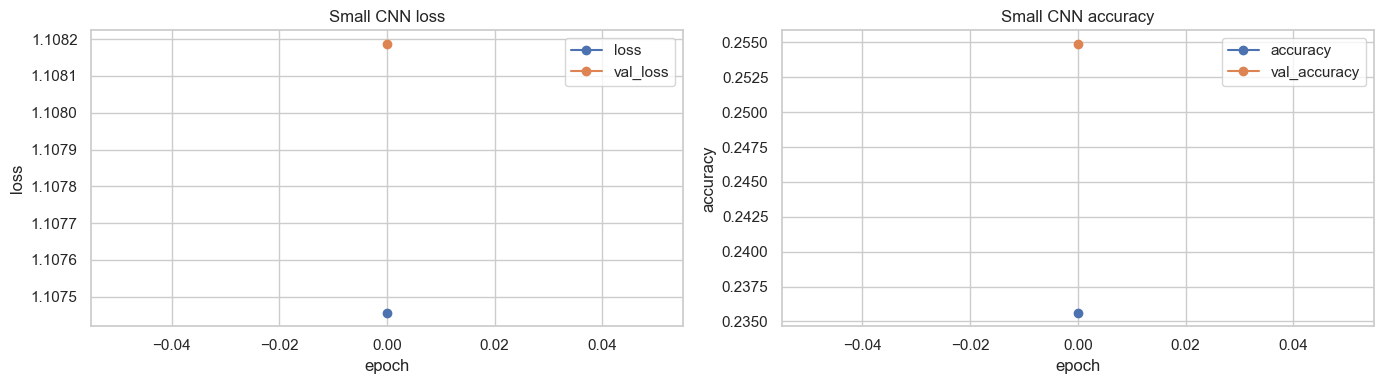

In [13]:
def plot_learning_curves(history: tf.keras.callbacks.History, title: str) -> None:
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    history_df[["loss", "val_loss"]].plot(ax=axes[0], marker="o")
    axes[0].set_title(f"{title} loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], marker="o")
    axes[1].set_title(f"{title} accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    plt.tight_layout()
    plt.show()

plot_learning_curves(small_history, "Small CNN")


## 9. MobileNetV2 Transfer Learning

The pretrained backbone starts frozen. The classifier head is trained on the same image sample used by the scratch CNN.


In [14]:
def build_transfer_model(input_shape: tuple[int, int, int], num_classes: int) -> tf.keras.Model:
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    backbone = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
    )
    backbone.trainable = False
    x = backbone(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs, name="mobilenetv2_transfer")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
        run_eagerly=True,
    )
    return model

transfer_model = build_transfer_model((*IMAGE_SIZE, 3), num_classes)
transfer_model.summary()


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
transfer_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

transfer_start = time.perf_counter()
transfer_history = fit_with_runtime_fallback(
    transfer_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=TRANSFER_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[transfer_early_stop],
    class_weight=class_weight,
    verbose=1,
)
transfer_train_time = time.perf_counter() - transfer_start
print(f"Transfer model train time: {transfer_train_time:.1f} seconds")


fit_with_runtime_fallback mode: train_on_batch
  train batch 1/3


  train batch 2/3


  train batch 3/3


Epoch 1/1 - loss: 1.6272 - accuracy: 0.2698 - val_loss: 1.4065 - val_accuracy: 0.3529
Transfer model train time: 0.7 seconds


## 10. Transfer Learning Curves


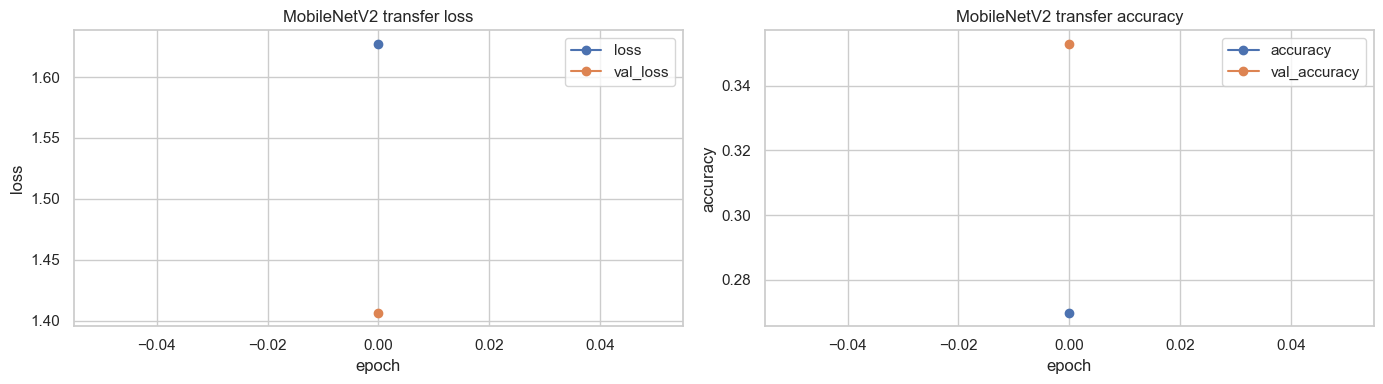

In [16]:
plot_learning_curves(transfer_history, "MobileNetV2 transfer")


## 11. Evaluation and Model Comparison


In [17]:
def predict_classes(model: tf.keras.Model, images: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    proba_parts = []
    for start in range(0, len(images), BATCH_SIZE):
        batch = images[start:start + BATCH_SIZE]
        proba_parts.append(model(batch, training=False).numpy())
    proba = np.vstack(proba_parts) if proba_parts else np.empty((0, num_classes))
    pred = np.argmax(proba, axis=1)
    confidence = np.max(proba, axis=1)
    return pred, confidence

small_val_pred, small_val_conf = predict_classes(small_cnn, X_val)
small_test_pred, small_test_conf = predict_classes(small_cnn, X_test)
transfer_val_pred, transfer_val_conf = predict_classes(transfer_model, X_val)
transfer_test_pred, transfer_test_conf = predict_classes(transfer_model, X_test)

comparison_rows = []
comparison_rows.extend(baseline_metrics)
comparison_rows.extend([
    metrics_from_predictions("small_cnn_from_scratch", "val", y_val, small_val_pred, small_cnn_train_time, len(y_train)),
    metrics_from_predictions("small_cnn_from_scratch", "test", y_test, small_test_pred, small_cnn_train_time, len(y_train)),
    metrics_from_predictions("mobilenetv2_transfer", "val", y_val, transfer_val_pred, transfer_train_time, len(y_train)),
    metrics_from_predictions("mobilenetv2_transfer", "test", y_test, transfer_test_pred, transfer_train_time, len(y_train)),
])

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(VISION_MODEL_COMPARISON_PATH, index=False)
comparison_df.to_csv(VISION_MODEL_COMPARISON_COMPAT_PATH, index=False)
display(comparison_df.sort_values(["split", "macro_f1"], ascending=[True, False]))

print(f"Saved comparison table to: {VISION_MODEL_COMPARISON_PATH.relative_to(PROJECT_ROOT)}")


,model,split,accuracy,macro_f1,weighted_f1,train_time_seconds,num_train_images
5,mobilenetv2_transfer,test,0.222222,0.194444,0.194444,0.683365,42
1,majority_baseline,test,0.333333,0.166667,0.166667,0.000273,42
3,small_cnn_from_scratch,test,0.333333,0.166667,0.166667,0.519013,42
4,mobilenetv2_transfer,val,0.555556,0.568254,0.568254,0.683365,42
0,majority_baseline,val,0.333333,0.166667,0.166667,0.000273,42
2,small_cnn_from_scratch,val,0.333333,0.166667,0.166667,0.519013,42


Saved comparison table to: report/vision_model_comparison.csv


In [18]:
print("Small CNN classification report - test")
print(classification_report(y_test, small_test_pred, target_names=class_names, zero_division=0))
print("MobileNetV2 transfer classification report - test")
print(classification_report(y_test, transfer_test_pred, target_names=class_names, zero_division=0))


Small CNN classification report - test
              precision    recall  f1-score   support

        high       0.00      0.00      0.00         3
         low       0.33      1.00      0.50         3
      medium       0.00      0.00      0.00         3

    accuracy                           0.33         9
   macro avg       0.11      0.33      0.17         9
weighted avg       0.11      0.33      0.17         9

MobileNetV2 transfer classification report - test
              precision    recall  f1-score   support

        high       0.00      0.00      0.00         3
         low       0.20      0.33      0.25         3
      medium       0.33      0.33      0.33         3

    accuracy                           0.22         9
   macro avg       0.18      0.22      0.19         9
weighted avg       0.18      0.22      0.19         9



## 12. Confusion Matrices


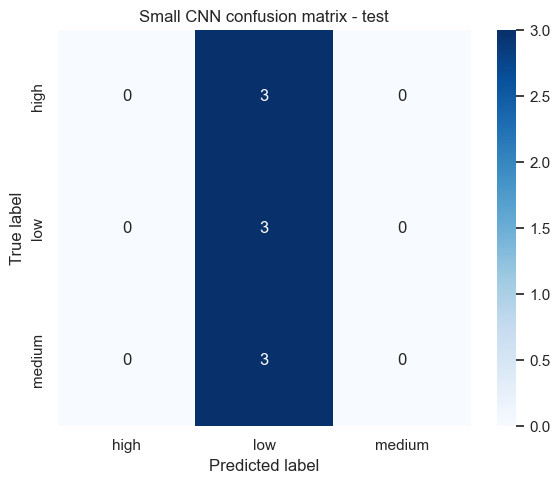

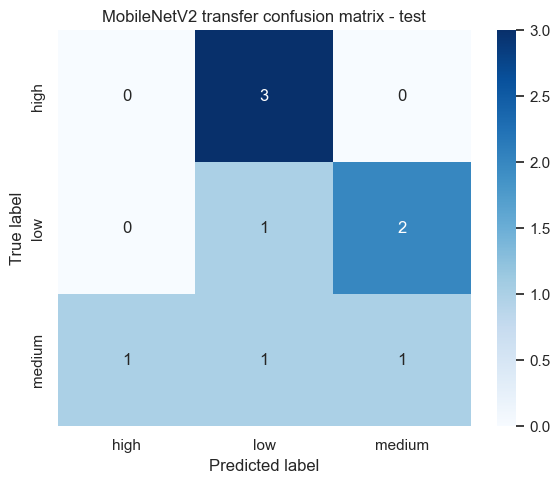

In [19]:
def plot_confusion(y_true: np.ndarray, y_pred: np.ndarray, title: str) -> None:
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

plot_confusion(y_test, small_test_pred, "Small CNN confusion matrix - test")
plot_confusion(y_test, transfer_test_pred, "MobileNetV2 transfer confusion matrix - test")


## 13. Sample Image Predictions

The grid below shows test-set product images with true label, predicted label, and confidence. It includes a mix of correct and incorrect predictions when errors are available.


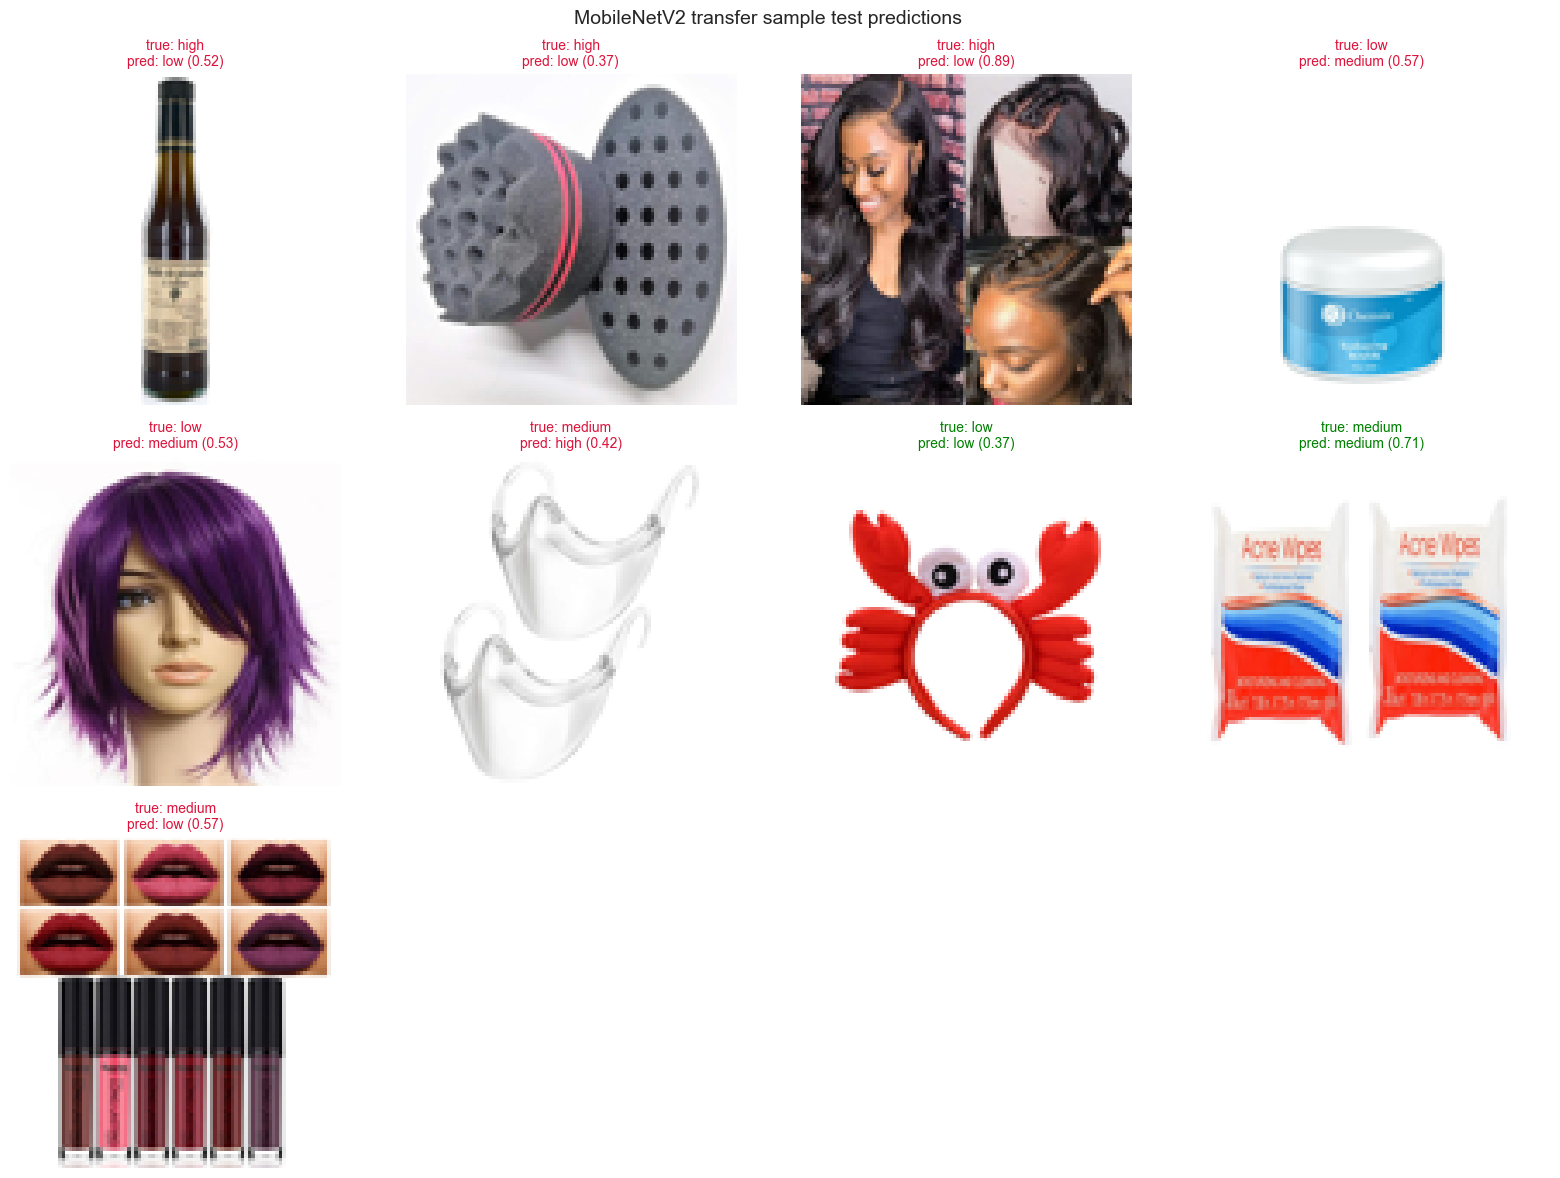

,product_id,product_title,cached_image_path,rating_band,true_label,predicted_label,confidence,correct
0,B00759LVR0,J. Leblanc French Pistachio Oil - 8 fl.oz. - Huile de Pistache,data/images/all_beauty/B00759LVR0_706f4ad8f6.jpg,high,high,low,0.520968,False
1,B0159D9ZJ4,Barber Sponge Brush Double Side 2 Different Wave Sizes 2 PC,data/images/all_beauty/B0159D9ZJ4_a1f6ba0898.jpg,high,high,low,0.366836,False
2,B08LYZY994,Body wave Lace Front Wigs Human Hair 4X4 Body Wave 150% Density Pre Plucked with Baby Hair Natural Black 100% Unproc...,data/images/all_beauty/B08LYZY994_2d0f9cfad0.jpg,high,high,low,0.888435,False
3,B01LFUCWKO,Argan Oil Hair Mask for Dry Damaged Hair - Keratin Complex Deep Conditioner for Color Treated Hair - Sulfate Free Ha...,data/images/all_beauty/B01LFUCWKO_e4300dbb7c.jpg,low,low,medium,0.566776,False
4,B07Y9JG82G,NUOBESTY Crab Headband Crab Costume Accessories Lobster Hair Hoops Plush Animal Hair Band Headwear for Halloween Dre...,data/images/all_beauty/B07Y9JG82G_30a41a313a.jpg,low,low,low,0.366449,True
5,B01C3Z6T68,Futuretrend40cm Layered Filp Out Heat-resist Theater Cosplay Wig-purple,data/images/all_beauty/B01C3Z6T68_c295ff08ec.jpg,low,low,medium,0.531597,False
6,B08XQFQ2RB,"Clear Face S_hield Transparent 100% Anti Fog (Medium, Anti-Fog 2Pcs)",data/images/all_beauty/B08XQFQ2RB_37bba0f184.jpg,medium,medium,high,0.416390,False
7,B072XG2DPK,"Women 6 Shades/Set Matte Lipstick , ONEMORES Women Waterproof Lip Gloss Makeup (B)",data/images/all_beauty/B072XG2DPK_970b0f66d1.jpg,medium,medium,low,0.570666,False
8,B07664G78D,Acne Wipes with salicylic acid 60 count (2 packs 30 wipes each),data/images/all_beauty/B07664G78D_2972ce83b0.jpg,medium,medium,medium,0.713032,True


In [20]:
def show_sample_predictions(image_df: pd.DataFrame, images: np.ndarray, y_true: np.ndarray, y_pred: np.ndarray, confidence: np.ndarray, model_name: str, n: int = 12) -> pd.DataFrame:
    pred_df = image_df[["product_id", "product_title", "cached_image_path", "rating_band"]].copy()
    pred_df["true_label"] = label_encoder.inverse_transform(y_true)
    pred_df["predicted_label"] = label_encoder.inverse_transform(y_pred)
    pred_df["confidence"] = confidence
    pred_df["correct"] = pred_df["true_label"] == pred_df["predicted_label"]

    incorrect_idx = pred_df.index[~pred_df["correct"]].tolist()
    correct_idx = pred_df.index[pred_df["correct"]].tolist()
    selected_idx = incorrect_idx[: n // 2] + correct_idx[: n - min(len(incorrect_idx), n // 2)]
    if len(selected_idx) < min(n, len(pred_df)):
        remaining = [idx for idx in pred_df.index.tolist() if idx not in selected_idx]
        selected_idx.extend(remaining[: min(n, len(pred_df)) - len(selected_idx)])
    selected_idx = selected_idx[: min(n, len(pred_df))]

    cols = 4
    rows = int(np.ceil(len(selected_idx) / cols)) if selected_idx else 1
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for ax, idx in zip(axes, selected_idx):
        ax.imshow(images[idx].astype("uint8"))
        row = pred_df.loc[idx]
        title = f"true: {row.true_label}\npred: {row.predicted_label} ({row.confidence:.2f})"
        ax.set_title(title, color=("green" if row.correct else "crimson"), fontsize=10)
        ax.axis("off")
    fig.suptitle(f"{model_name} sample test predictions", fontsize=14)
    plt.tight_layout()
    plt.show()
    return pred_df

sample_prediction_df = show_sample_predictions(
    test_images_df,
    X_test,
    y_test,
    transfer_test_pred,
    transfer_test_conf,
    "MobileNetV2 transfer",
    n=12,
)
display(sample_prediction_df.head(12))


## 14. Save Artifacts


In [21]:
small_cnn.save(SMALL_CNN_MODEL_PATH)
transfer_model.save(TRANSFER_MODEL_PATH)

test_predictions = test_images_df[["product_id", "product_title", "target_rating", "rating_band", "cached_image_path"]].copy()
test_predictions["small_cnn_predicted_label"] = label_encoder.inverse_transform(small_test_pred)
test_predictions["small_cnn_confidence"] = small_test_conf
test_predictions["transfer_predicted_label"] = label_encoder.inverse_transform(transfer_test_pred)
test_predictions["transfer_confidence"] = transfer_test_conf
test_predictions.to_csv(VISION_PREDICTIONS_TEST_PATH, index=False)

print(f"Saved small CNN model to: {SMALL_CNN_MODEL_PATH.relative_to(PROJECT_ROOT)}")
print(f"Saved transfer model to: {TRANSFER_MODEL_PATH.relative_to(PROJECT_ROOT)}")
print(f"Saved test predictions to: {VISION_PREDICTIONS_TEST_PATH.relative_to(PROJECT_ROOT)}")


Saved small CNN model to: models/vision_small_cnn.keras
Saved transfer model to: models/vision_mobilenetv2_transfer.keras
Saved test predictions to: data/processed/vision_predictions_test.csv


## 15. Final Milestone 2 Summary

This summary is generated from the actual run. If transfer learning does not outperform the small CNN in the quick run, likely reasons include small image sample size, noisy rating-band labels, weak visual signal for rating quality, broken or low-quality product images, or insufficient fine-tuning.


In [22]:
split_distribution = {
    "train": train_images_df["rating_band"].value_counts().sort_index().to_dict(),
    "val": val_images_df["rating_band"].value_counts().sort_index().to_dict(),
    "test": test_images_df["rating_band"].value_counts().sort_index().to_dict(),
}

val_only = comparison_df[comparison_df["split"] == "val"].copy()
best_val_row = val_only.sort_values("macro_f1", ascending=False).iloc[0]

print("Milestone 2 Computer Vision Summary")
print("=" * 42)
print(f"Train/validation/test images: {len(train_images_df)} / {len(val_images_df)} / {len(test_images_df)}")
print(f"Class distribution per split: {split_distribution}")
print(f"Leakage check passed: {leakage_check_passed}; overlaps={leakage_summary}")
print("\nBaseline metrics:")
print(comparison_df[comparison_df["model"] == "majority_baseline"].to_string(index=False))
print("\nSmall CNN metrics:")
print(comparison_df[comparison_df["model"] == "small_cnn_from_scratch"].to_string(index=False))
print("\nTransfer learning metrics:")
print(comparison_df[comparison_df["model"] == "mobilenetv2_transfer"].to_string(index=False))
print(f"\nBest validation macro-F1: {best_val_row['model']} ({best_val_row['macro_f1']:.4f})")
print("\nSaved outputs:")
for output_path in [VISION_MODEL_COMPARISON_PATH, VISION_MODEL_COMPARISON_COMPAT_PATH, VISION_PREDICTIONS_TEST_PATH, SMALL_CNN_MODEL_PATH, TRANSFER_MODEL_PATH, VISION_LABEL_ENCODER_PATH]:
    print(f"- {output_path.relative_to(PROJECT_ROOT)}")


Milestone 2 Computer Vision Summary
Train/validation/test images: 42 / 9 / 9
Class distribution per split: {'train': {'high': 14, 'low': 14, 'medium': 14}, 'val': {'high': 3, 'low': 3, 'medium': 3}, 'test': {'high': 3, 'low': 3, 'medium': 3}}
Leakage check passed: True; overlaps={'train_val_overlap': 0, 'train_test_overlap': 0, 'val_test_overlap': 0}

Baseline metrics:
            model split  accuracy  macro_f1  weighted_f1  train_time_seconds  num_train_images
majority_baseline   val  0.333333  0.166667     0.166667            0.000273                42
majority_baseline  test  0.333333  0.166667     0.166667            0.000273                42

Small CNN metrics:
                 model split  accuracy  macro_f1  weighted_f1  train_time_seconds  num_train_images
small_cnn_from_scratch   val  0.333333  0.166667     0.166667            0.519013                42
small_cnn_from_scratch  test  0.333333  0.166667     0.166667            0.519013                42

Transfer learning metr